Name: Prakhar Tyagi
URN : 2481010
section: b 
lab Subject : Introduction to Machine learning 
Experiment 2

## 1. Import Libraries

We use Pandas for data handling, NumPy for numerical operations, and Matplotlib for visualization.

In [2]:
print("Name: prakhar tyagi")
print("URN: 2481010")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")

Name: prakhar tyagi
URN: 2481010
Libraries imported successfully.


## 2. Load and Clean the Dataset

The file uses `;` as its separator and `,` as its decimal mark. The final two columns are empty artifacts from the original file. The value `-200` represents a missing measurement, so it is replaced with `NaN`.

In [3]:
print("Name: prakhar tyagi")
print("URN: 2481010")

DATA_PATH = "AirQualityUCI.csv"

raw_df = pd.read_csv(DATA_PATH, sep=";", decimal=",")

# Remove columns that are completely empty and convert the dataset's sentinel to NaN.
df = raw_df.dropna(axis=1, how="all").replace(-200, np.nan)

# Combine the separate date and time fields into one datetime index.
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# The source file includes trailing blank records and duplicate rows.
df = (
    df.dropna(subset=["datetime"])
      .drop_duplicates()
      .sort_values("datetime")
      .reset_index(drop=True)
)

print("Raw shape:", raw_df.shape)
print("Cleaned shape:", df.shape)
print("Sentinel values converted to missing values.")
display(df.head())

Name: prakhar tyagi
URN: 2481010
Raw shape: (9471, 17)
Cleaned shape: (9357, 16)
Sentinel values converted to missing values.


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
0,10/03/2004,18.00.00,2.60,"1,360.00",150.00,11.90,"1,046.00",166.00,"1,056.00",113.00,"1,692.00","1,268.00",13.60,48.90,0.76,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.00,"1,292.00",112.00,9.40,955.00,103.00,"1,174.00",92.00,"1,559.00",972.00,13.30,47.70,0.73,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.20,"1,402.00",88.00,9.00,939.00,131.00,"1,140.00",114.00,"1,555.00","1,074.00",11.90,54.00,0.75,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.20,"1,376.00",80.00,9.20,948.00,172.00,"1,092.00",122.00,"1,584.00","1,203.00",11.00,60.00,0.79,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.60,"1,272.00",51.00,6.50,836.00,131.00,"1,205.00",116.00,"1,490.00","1,110.00",11.20,59.60,0.79,2004-03-10 22:00:00


## 3. Initial Inspection

Inspect the first and last records, dimensions, column names, data types, and memory usage before drawing conclusions.

In [4]:
print("Name: prakhar tyagi")
print("URN: 2481010")

print("First five rows")
display(df.head())

print("Last five rows")
display(df.tail())

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approximate memory usage: {memory_mb:.2f} MB")

Name: prakhar tyagi
URN: 2481010
First five rows


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
0,10/03/2004,18.00.00,2.60,"1,360.00",150.00,11.90,"1,046.00",166.00,"1,056.00",113.00,"1,692.00","1,268.00",13.60,48.90,0.76,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.00,"1,292.00",112.00,9.40,955.00,103.00,"1,174.00",92.00,"1,559.00",972.00,13.30,47.70,0.73,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.20,"1,402.00",88.00,9.00,939.00,131.00,"1,140.00",114.00,"1,555.00","1,074.00",11.90,54.00,0.75,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.20,"1,376.00",80.00,9.20,948.00,172.00,"1,092.00",122.00,"1,584.00","1,203.00",11.00,60.00,0.79,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.60,"1,272.00",51.00,6.50,836.00,131.00,"1,205.00",116.00,"1,490.00","1,110.00",11.20,59.60,0.79,2004-03-10 22:00:00


Last five rows


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
9352,04/04/2005,10.00.00,3.10,"1,314.00",NaN,13.50,"1,101.00",472.00,539.00,190.00,"1,374.00","1,729.00",21.90,29.30,0.76,2005-04-04 10:00:00
9353,04/04/2005,11.00.00,2.40,"1,163.00",NaN,11.40,"1,027.00",353.00,604.00,179.00,"1,264.00","1,269.00",24.30,23.70,0.71,2005-04-04 11:00:00
9354,04/04/2005,12.00.00,2.40,"1,142.00",NaN,12.40,"1,063.00",293.00,603.00,175.00,"1,241.00","1,092.00",26.90,18.30,0.64,2005-04-04 12:00:00
9355,04/04/2005,13.00.00,2.10,"1,003.00",NaN,9.50,961.00,235.00,702.00,156.00,"1,041.00",770.00,28.30,13.50,0.51,2005-04-04 13:00:00
9356,04/04/2005,14.00.00,2.20,"1,071.00",NaN,11.90,"1,047.00",265.00,654.00,168.00,"1,129.00",816.00,28.50,13.10,0.50,2005-04-04 14:00:00


Shape: (9357, 16)

Columns:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'datetime']

Data types:


,dtype
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


Approximate memory usage: 2.03 MB


## 4. Data Quality Assessment

### Missing Values

Missing values are important because they affect summary statistics, plots, and later modelling. The table below reports both counts and percentages.

In [9]:
print("Name: prakhar tyagi")
print("URN: 2481010")

missing_count = df.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": (missing_count / len(df) * 100).round(2)
})
display(missing_table)

print("Duplicate rows:", df.duplicated().sum())
print("Invalid datetime values:", df["datetime"].isna().sum())

Name: prakhar tyagi
URN: 2481010


,Missing Values,Missing Percentage
NMHC(GT),8443,90.23
CO(GT),1683,17.99
NO2(GT),1642,17.55
NOx(GT),1639,17.52
C6H6(GT),366,3.91
PT08.S2(NMHC),366,3.91
PT08.S3(NOx),366,3.91
PT08.S1(CO),366,3.91
T,366,3.91
RH,366,3.91


Duplicate rows: 0
Invalid datetime values: 0


### Missingness Visualization

A bar chart helps compare missing-value percentages across pollutant and weather variables.

Name: prakhar tyagi
URN: 2481010


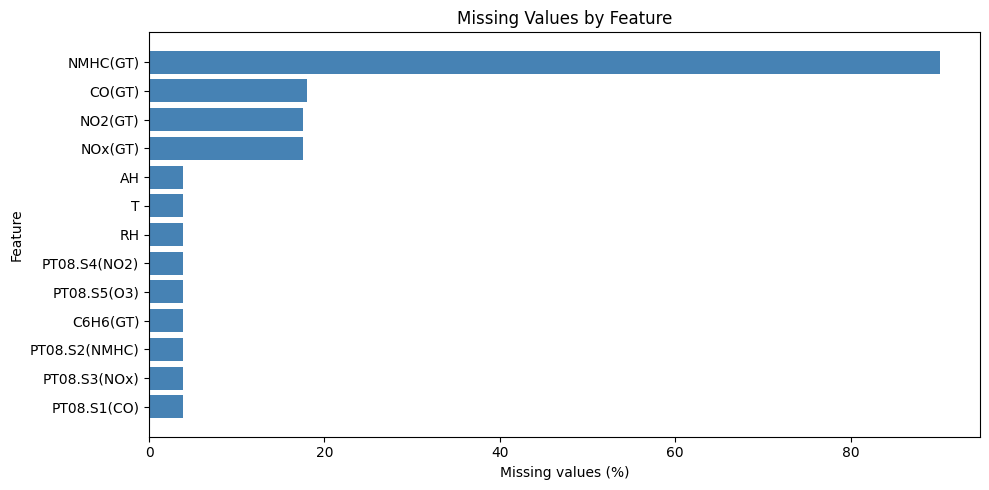

In [7]:
print("Name: prakhar tyagi")
print("URN: 2481010")

plot_missing = missing_table[missing_table["Missing Values"] > 0].sort_values("Missing Percentage")

plt.figure(figsize=(10, 5))
plt.barh(plot_missing.index, plot_missing["Missing Percentage"], color="steelblue")
plt.title("Missing Values by Feature")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 5. Descriptive Statistics

The numerical summary shows central tendency, spread, and range. Because missing values are now `NaN`, Pandas excludes them from these calculations.

In [6]:
print("Name: prakhar tyagi")
print("URN: 2481010")

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

summary = df[numeric_columns].describe().T
summary["missing"] = df[numeric_columns].isna().sum()
summary["skewness"] = df[numeric_columns].skew()
display(summary.round(3))

Name: prakhar tyagi
URN: 2481010


,count,mean,std,min,25%,50%,75%,max,missing,skewness
CO(GT),"7,674.00",2.15,1.45,0.10,1.10,1.80,2.90,11.90,1683,1.37
PT08.S1(CO),"8,991.00","1,099.83",217.08,647.00,937.00,"1,063.00","1,231.00","2,040.00",366,0.76
NMHC(GT),914.00,218.81,204.46,7.00,67.00,150.00,297.00,"1,189.00",8443,1.56
C6H6(GT),"8,991.00",10.08,7.45,0.10,4.40,8.20,14.00,63.70,366,1.36
PT08.S2(NMHC),"8,991.00",939.15,266.83,383.00,734.50,909.00,"1,116.00","2,214.00",366,0.56
NOx(GT),"7,718.00",246.90,212.98,2.00,98.00,180.00,326.00,"1,479.00",1639,1.72
PT08.S3(NOx),"8,991.00",835.49,256.82,322.00,658.00,806.00,969.50,"2,683.00",366,1.10
NO2(GT),"7,715.00",113.09,48.37,2.00,78.00,109.00,142.00,340.00,1642,0.62
PT08.S4(NO2),"8,991.00","1,456.27",346.21,551.00,"1,227.00","1,463.00","1,674.00","2,775.00",366,0.20
PT08.S5(O3),"8,991.00","1,022.91",398.48,221.00,731.50,963.00,"1,273.50","2,523.00",366,0.63


# Part L — Complete Univariate EDA

Univariate EDA examines one variable at a time. For this dataset, it includes:

- frequency and proportion tables for time-based categorical features
- measures of central tendency and dispersion
- histograms
- density curves
- ECDF plots
- boxplots
- violin plots
- skewness and kurtosis

In [13]:
print("Name: prakhar tyagi")
print("URN: 2481010")

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["month_name"] = df["datetime"].dt.month_name()
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()

pollutant_columns = [
    "CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"
]
sensor_columns = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)"
]
weather_columns = ["T", "RH", "AH"]
analysis_columns = pollutant_columns + sensor_columns + weather_columns

categorical_time_columns = ["year", "month_name", "hour", "weekday"]

for column in categorical_time_columns:
    frequency_table = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Count")
    )
    frequency_table["Percentage"] = (
        frequency_table["Count"] / len(df) * 100
    ).round(2)
    print(f"Frequency distribution of {column}")
    display(frequency_table)

print("Unique values in each analysis column:")
display(df[analysis_columns].nunique().sort_values().to_frame("unique_values"))

Name: prakhar tyagi
URN: 2481010
Frequency distribution of year


,year,Count,Percentage
0,2004,7110,75.99
1,2005,2247,24.01


Frequency distribution of month_name


,month_name,Count,Percentage
0,March,1254,13.40
1,April,807,8.62
2,May,744,7.95
3,July,744,7.95
4,January,744,7.95
5,August,744,7.95
6,October,744,7.95
7,December,744,7.95
8,June,720,7.69
9,September,720,7.69


Frequency distribution of hour


,hour,Count,Percentage
0,18,390,4.17
1,19,390,4.17
2,20,390,4.17
3,21,390,4.17
4,22,390,4.17
5,23,390,4.17
6,0,390,4.17
7,1,390,4.17
8,2,390,4.17
9,3,390,4.17


Frequency distribution of weekday


,weekday,Count,Percentage
0,Thursday,1344,14.36
1,Friday,1344,14.36
2,Saturday,1344,14.36
3,Sunday,1344,14.36
4,Monday,1335,14.27
5,Wednesday,1326,14.17
6,Tuesday,1320,14.11


Unique values in each analysis column:


,unique_values
CO(GT),96
NO2(GT),283
C6H6(GT),407
NMHC(GT),429
T,436
RH,753
NOx(GT),925
PT08.S1(CO),1041
PT08.S3(NOx),1221
PT08.S2(NMHC),1245


## Numerical Summary: Centre, Spread, and Shape

Mean, median, mode, range, variance, coefficient of variation, skewness, and kurtosis describe different aspects of each numerical distribution.

In [15]:
print("Name: prakhar tyagi")
print("URN: 2481010")

univariate_summary = pd.DataFrame(index=analysis_columns)
univariate_summary["Count"] = df[analysis_columns].count()
univariate_summary["Missing"] = df[analysis_columns].isna().sum()
univariate_summary["Mean"] = df[analysis_columns].mean()
univariate_summary["Median"] = df[analysis_columns].median()
univariate_summary["Mode"] = df[analysis_columns].mode().iloc[0]
univariate_summary["Minimum"] = df[analysis_columns].min()
univariate_summary["Maximum"] = df[analysis_columns].max()
univariate_summary["Range"] = univariate_summary["Maximum"] - univariate_summary["Minimum"]
univariate_summary["Variance"] = df[analysis_columns].var()
univariate_summary["Std Dev"] = df[analysis_columns].std()
univariate_summary["CV (%)"] = (
    univariate_summary["Std Dev"] / univariate_summary["Mean"].abs() * 100
)
univariate_summary["Skewness"] = df[analysis_columns].skew()
univariate_summary["Kurtosis"] = df[analysis_columns].kurtosis()

display(univariate_summary.round(3))

Name: prakhar tyagi
URN: 2481010


,Count,Missing,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Std Dev,CV (%),Skewness,Kurtosis
CO(GT),7674,1683,2.15,1.80,1.00,0.10,11.90,11.80,2.11,1.45,67.51,1.37,2.67
NMHC(GT),914,8443,218.81,150.00,66.00,7.00,"1,189.00","1,182.00","41,803.86",204.46,93.44,1.56,2.27
C6H6(GT),8991,366,10.08,8.20,3.60,0.10,63.70,63.60,55.50,7.45,73.88,1.36,2.49
NOx(GT),7718,1639,246.90,180.00,89.00,2.00,"1,479.00","1,477.00","45,360.13",212.98,86.26,1.72,3.40
NO2(GT),7715,1642,113.09,109.00,97.00,2.00,340.00,338.00,"2,339.67",48.37,42.77,0.62,0.47
PT08.S1(CO),8991,366,"1,099.83","1,063.00",973.00,647.00,"2,040.00","1,393.00","47,123.74",217.08,19.74,0.76,0.34
PT08.S2(NMHC),8991,366,939.15,909.00,853.00,383.00,"2,214.00","1,831.00","71,199.01",266.83,28.41,0.56,0.06
PT08.S3(NOx),8991,366,835.49,806.00,733.00,322.00,"2,683.00","2,361.00","65,955.14",256.82,30.74,1.10,2.68
PT08.S4(NO2),8991,366,"1,456.27","1,463.00","1,488.00",551.00,"2,775.00","2,224.00","119,859.14",346.21,23.77,0.20,0.08
PT08.S5(O3),8991,366,"1,022.91",963.00,825.00,221.00,"2,523.00","2,302.00","158,789.73",398.48,38.96,0.63,0.08


## Histograms for Every Numerical Feature

The earlier pollutant-only plot is supplemented here with all pollutant, sensor, and weather variables. Each feature gets its own scale so distributions remain readable.

Name: prakhar tyagi
URN: 2481010


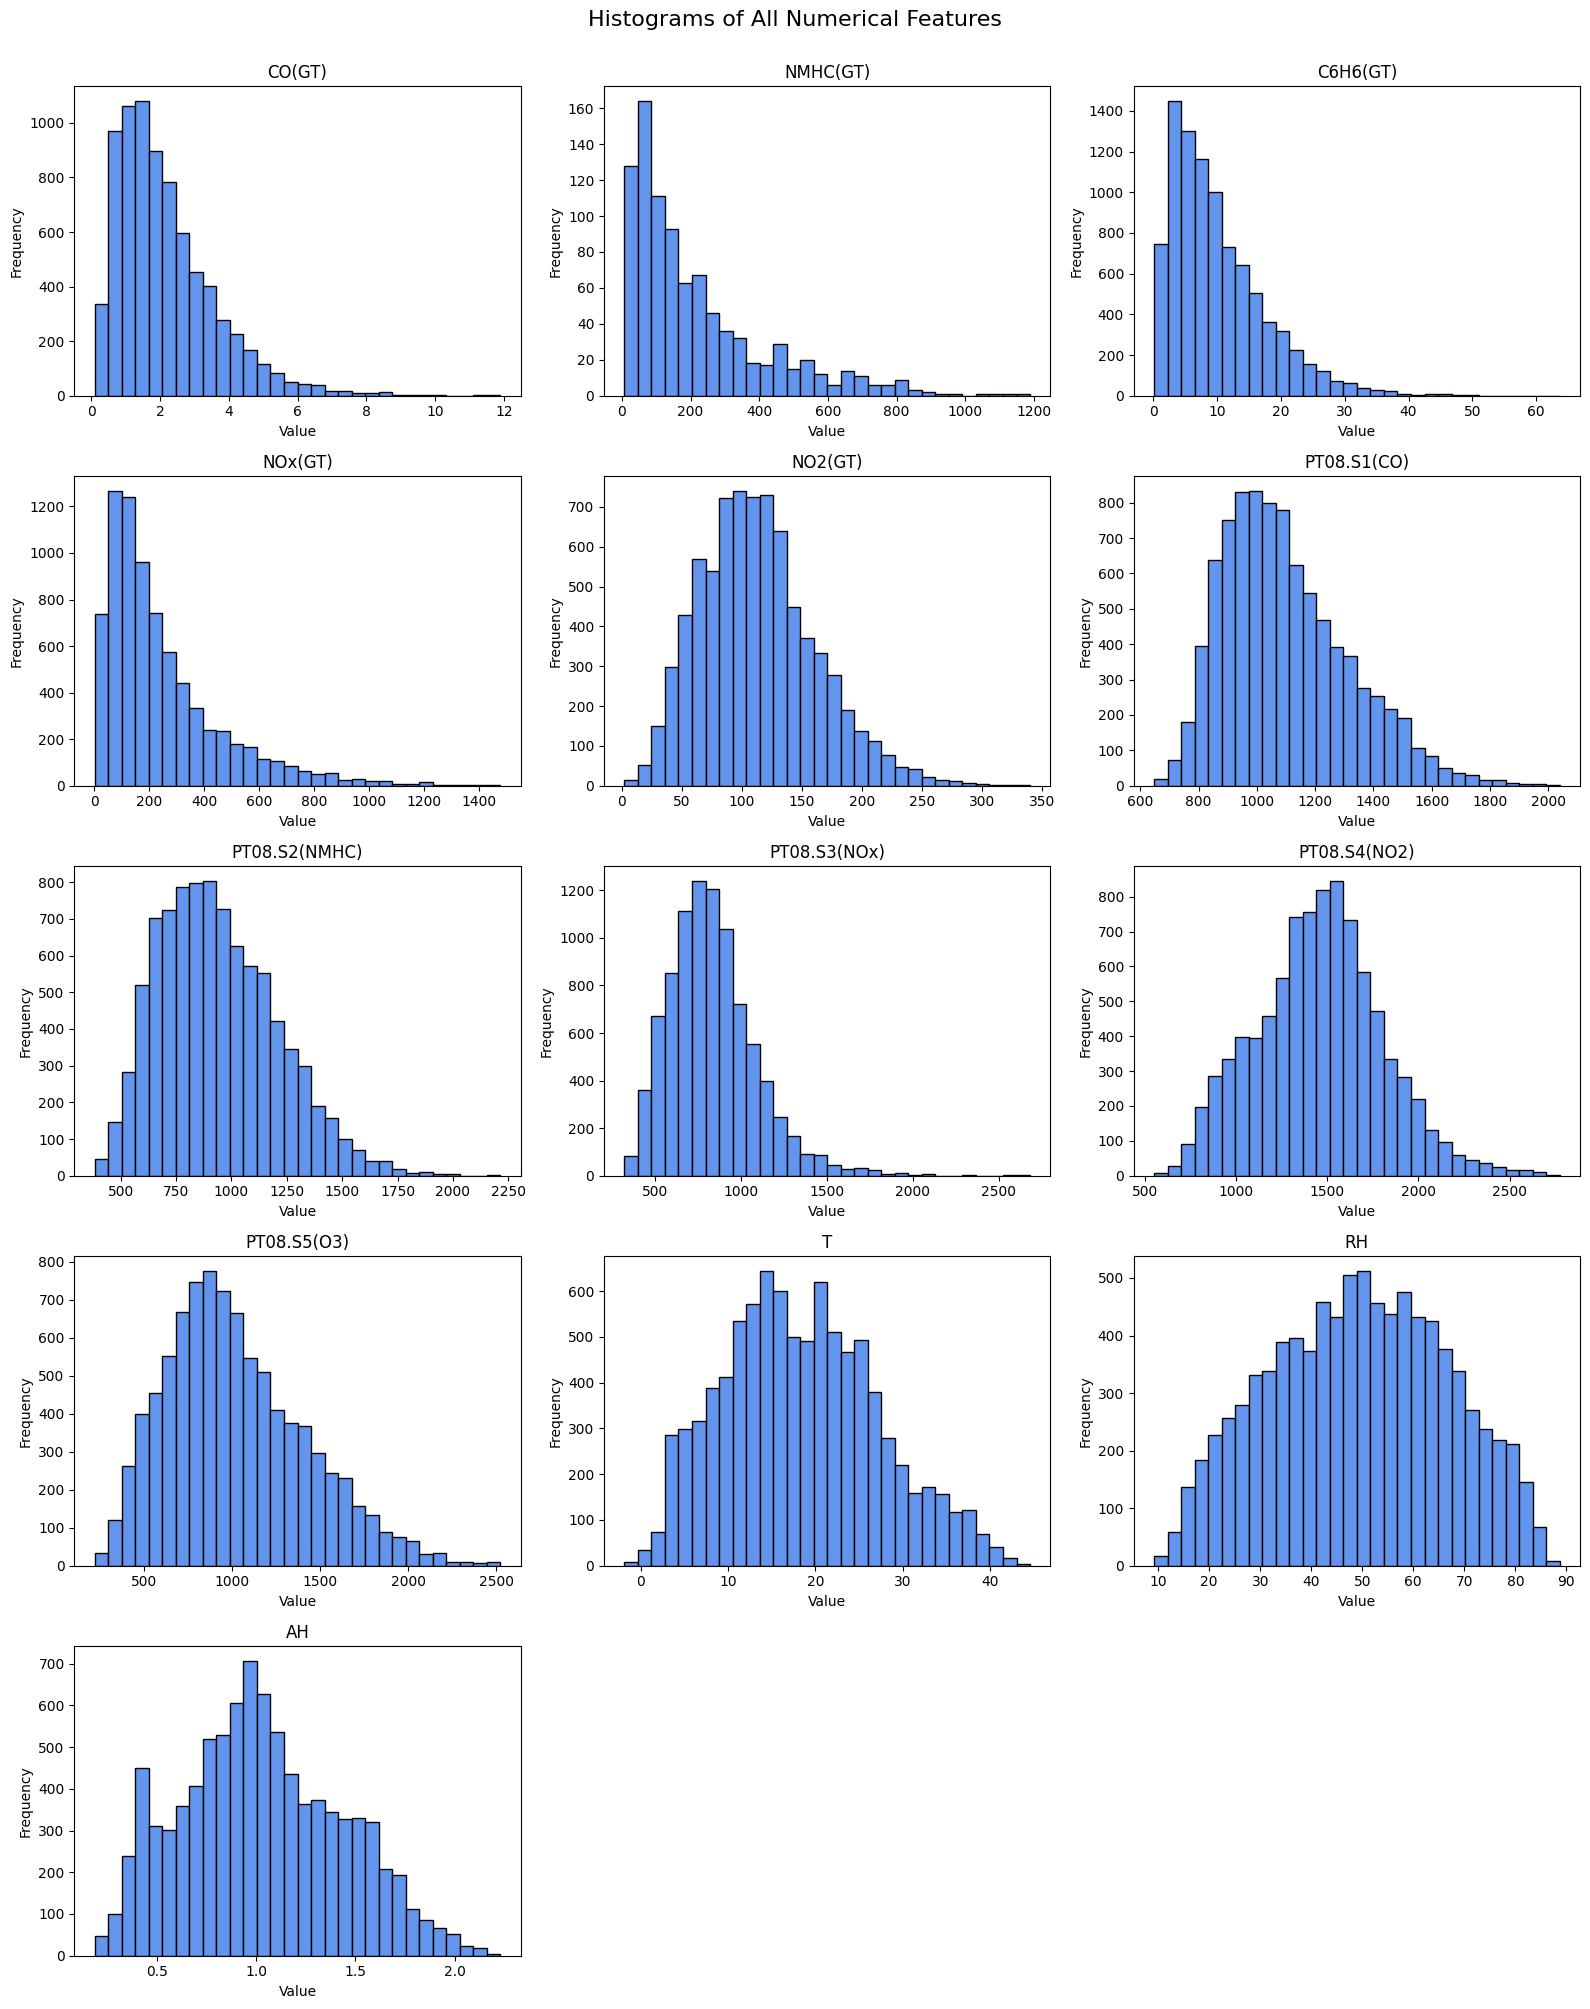

In [16]:
print("Name: prakhar tyagi")
print("URN: 2481010")

histogram_columns = analysis_columns
n_columns = 3
n_rows = int(np.ceil(len(histogram_columns) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 4 * n_rows))
axes = np.asarray(axes).ravel()

for axis, column in zip(axes, histogram_columns):
    axis.hist(df[column].dropna(), bins=30, edgecolor="black", color="cornflowerblue")
    axis.set_title(column)
    axis.set_xlabel("Value")
    axis.set_ylabel("Frequency")

for axis in axes[len(histogram_columns):]:
    axis.axis("off")

fig.suptitle("Histograms of All Numerical Features", y=1.002, fontsize=16)
plt.tight_layout()
plt.show()

## Density Curves, ECDFs, Boxplots, and Violin Plots

These plots show distribution shape from complementary perspectives:

- density curves show where observations concentrate
- ECDFs show the proportion of observations below each value
- boxplots summarize quartiles and flagged extremes
- violin plots combine a boxplot-like summary with distribution shape

Name: prakhar tyagi
URN: 2481010


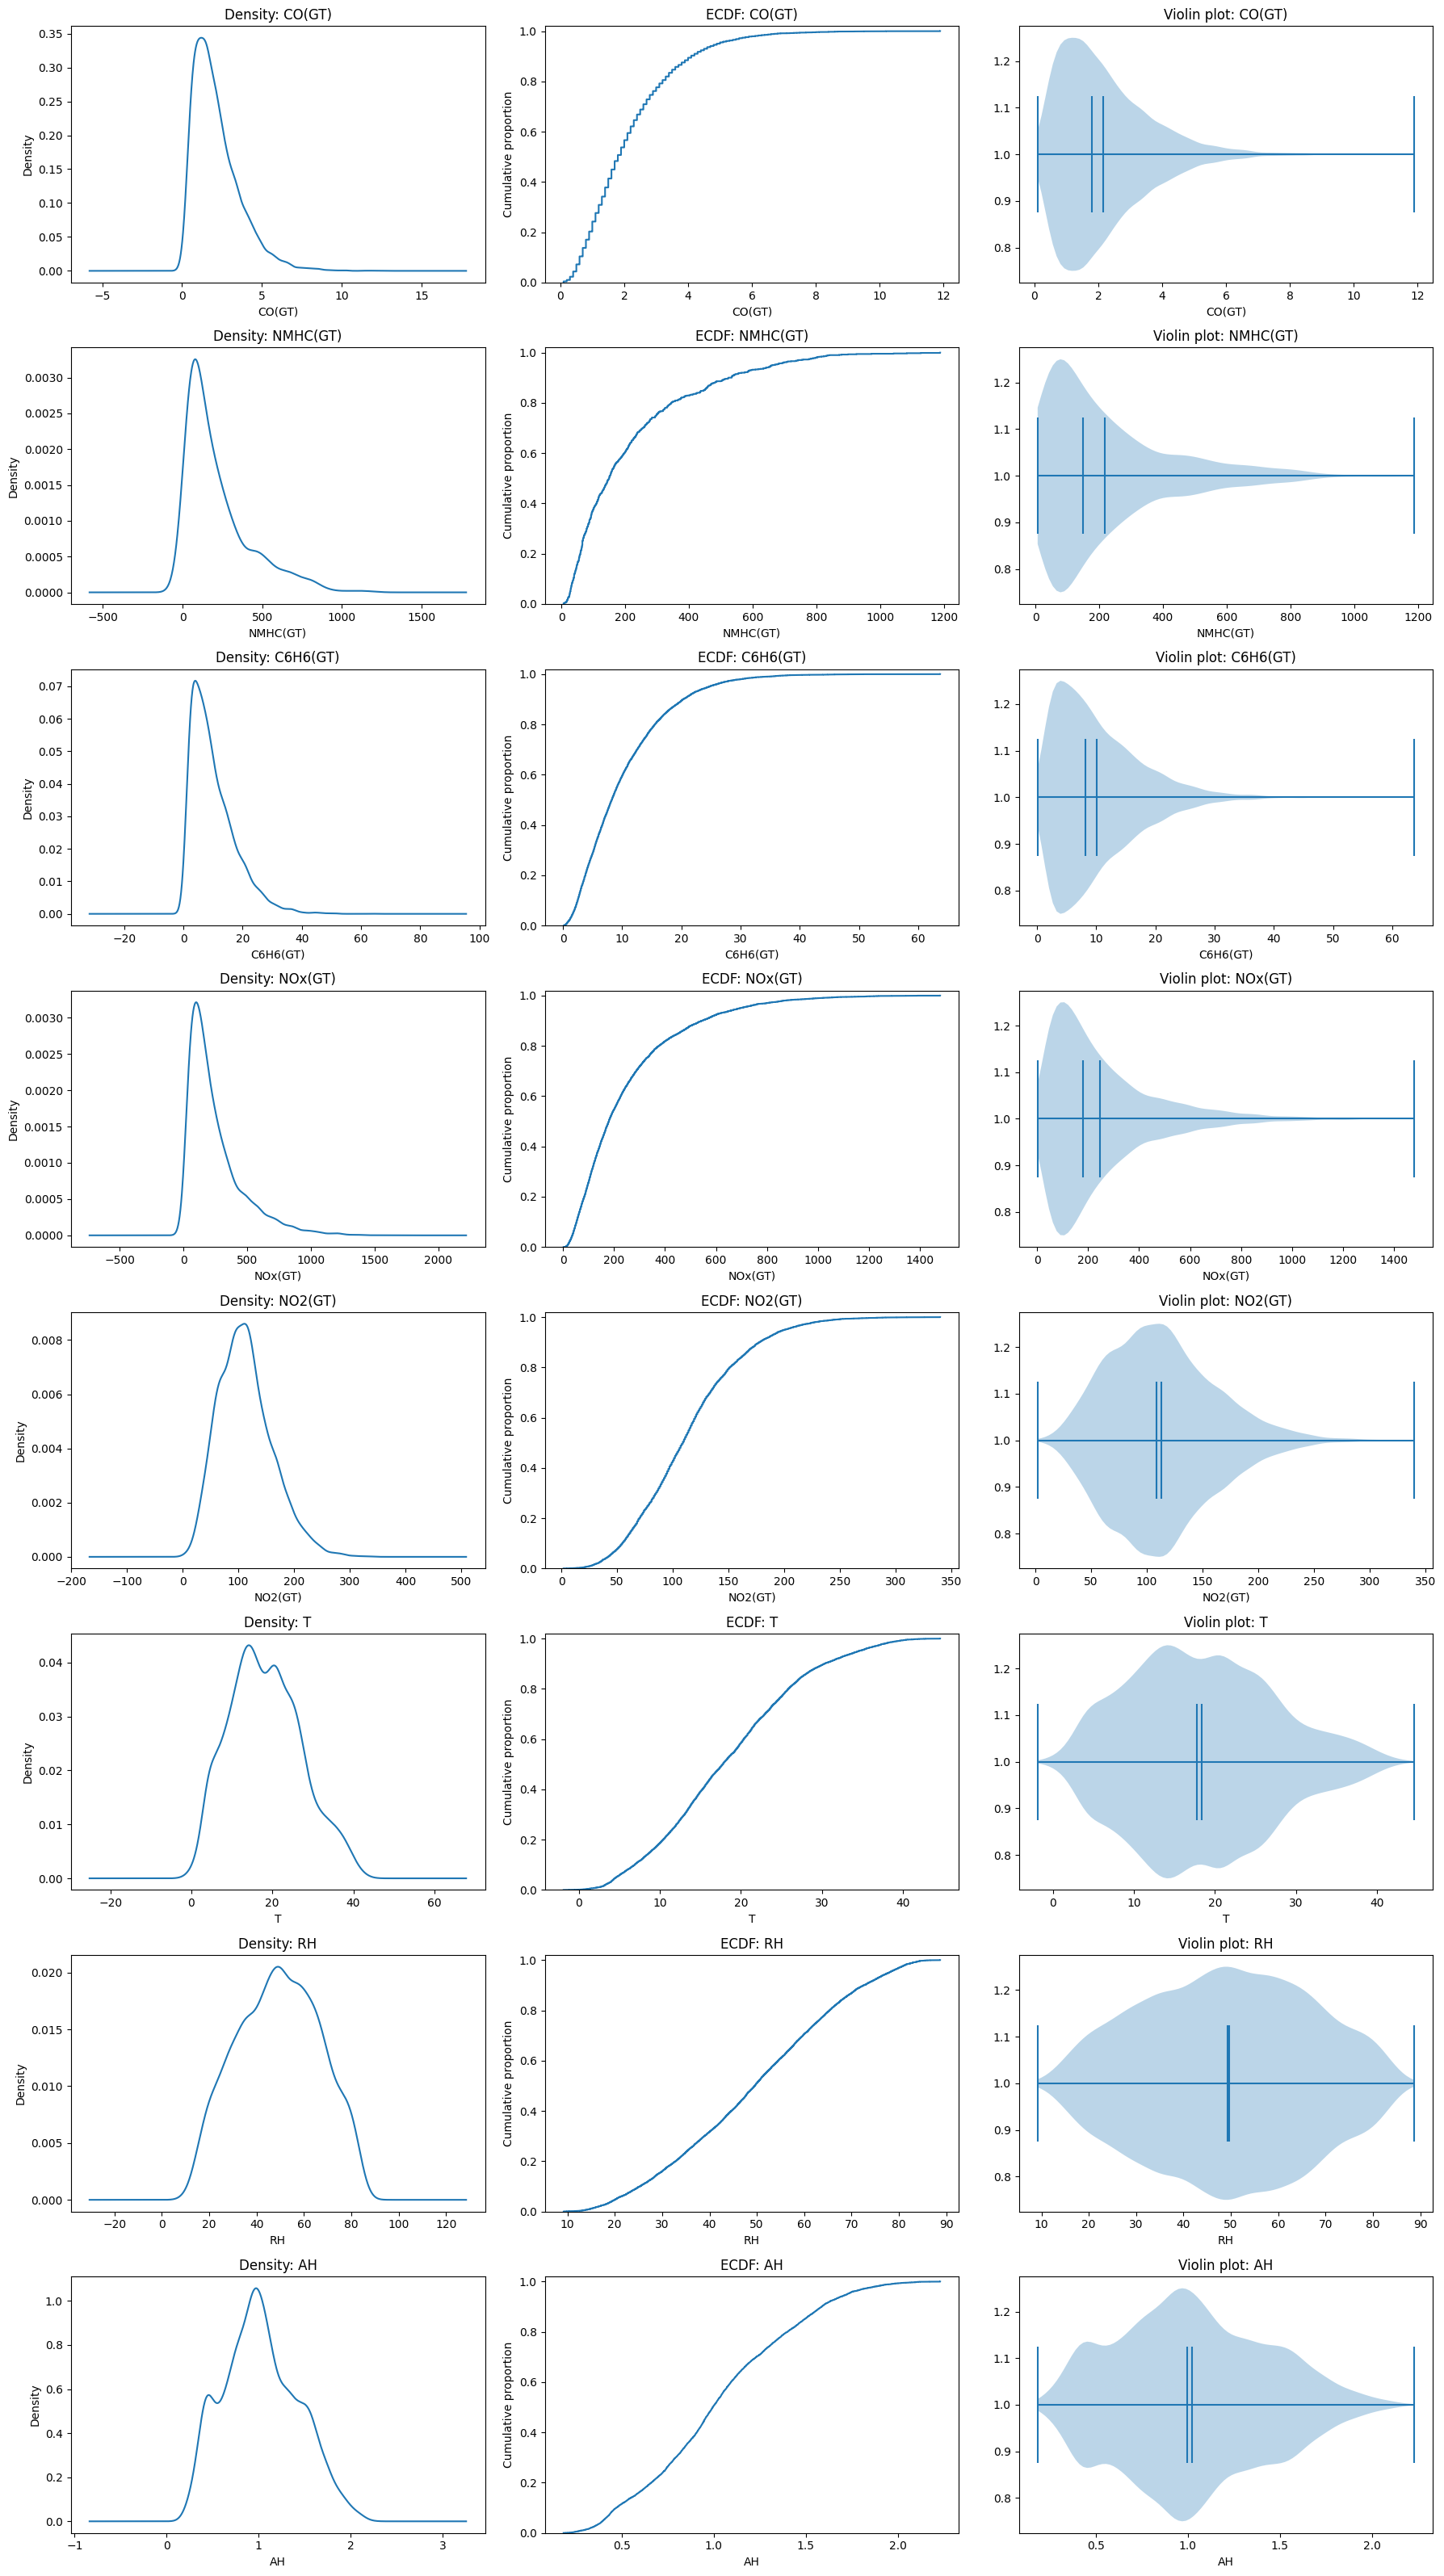

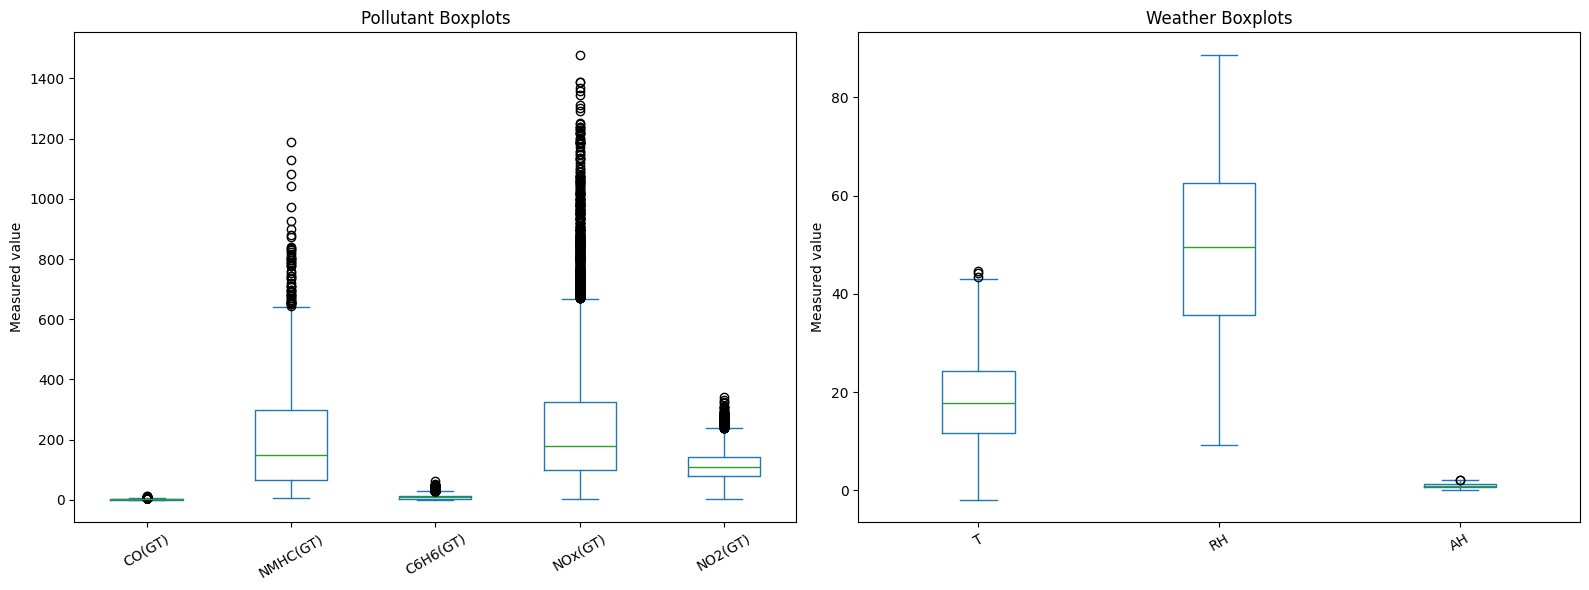

In [17]:
print("Name: prakhar tyagi")
print("URN: 2481010")

plot_columns = pollutant_columns + weather_columns

fig, axes = plt.subplots(len(plot_columns), 3, figsize=(18, 4 * len(plot_columns)))
for row, column in enumerate(plot_columns):
    values = df[column].dropna().sort_values().to_numpy()
    density_axis, ecdf_axis, violin_axis = axes[row]

    df[column].dropna().plot(kind="density", ax=density_axis)
    density_axis.set_title(f"Density: {column}")
    density_axis.set_xlabel(column)
    density_axis.set_ylabel("Density")

    ecdf_axis.step(values, np.arange(1, len(values) + 1) / len(values), where="post")
    ecdf_axis.set_title(f"ECDF: {column}")
    ecdf_axis.set_xlabel(column)
    ecdf_axis.set_ylabel("Cumulative proportion")
    ecdf_axis.set_ylim(0, 1.02)

    violin_axis.violinplot(values, vert=False, showmeans=True, showmedians=True)
    violin_axis.set_title(f"Violin plot: {column}")
    violin_axis.set_xlabel(column)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df[pollutant_columns].plot(kind="box", ax=axes[0], rot=30)
axes[0].set_title("Pollutant Boxplots")
axes[0].set_ylabel("Measured value")
df[weather_columns].plot(kind="box", ax=axes[1], rot=30)
axes[1].set_title("Weather Boxplots")
axes[1].set_ylabel("Measured value")
plt.tight_layout()
plt.show()

## Q-Q Plots for Distribution Shape

A Q-Q plot compares observed values with theoretical normal quantiles. Points close to a straight line suggest approximate normality; systematic curves or tail departures indicate skewness or heavy tails.

Name: prakhar tyagi
URN: 2481010


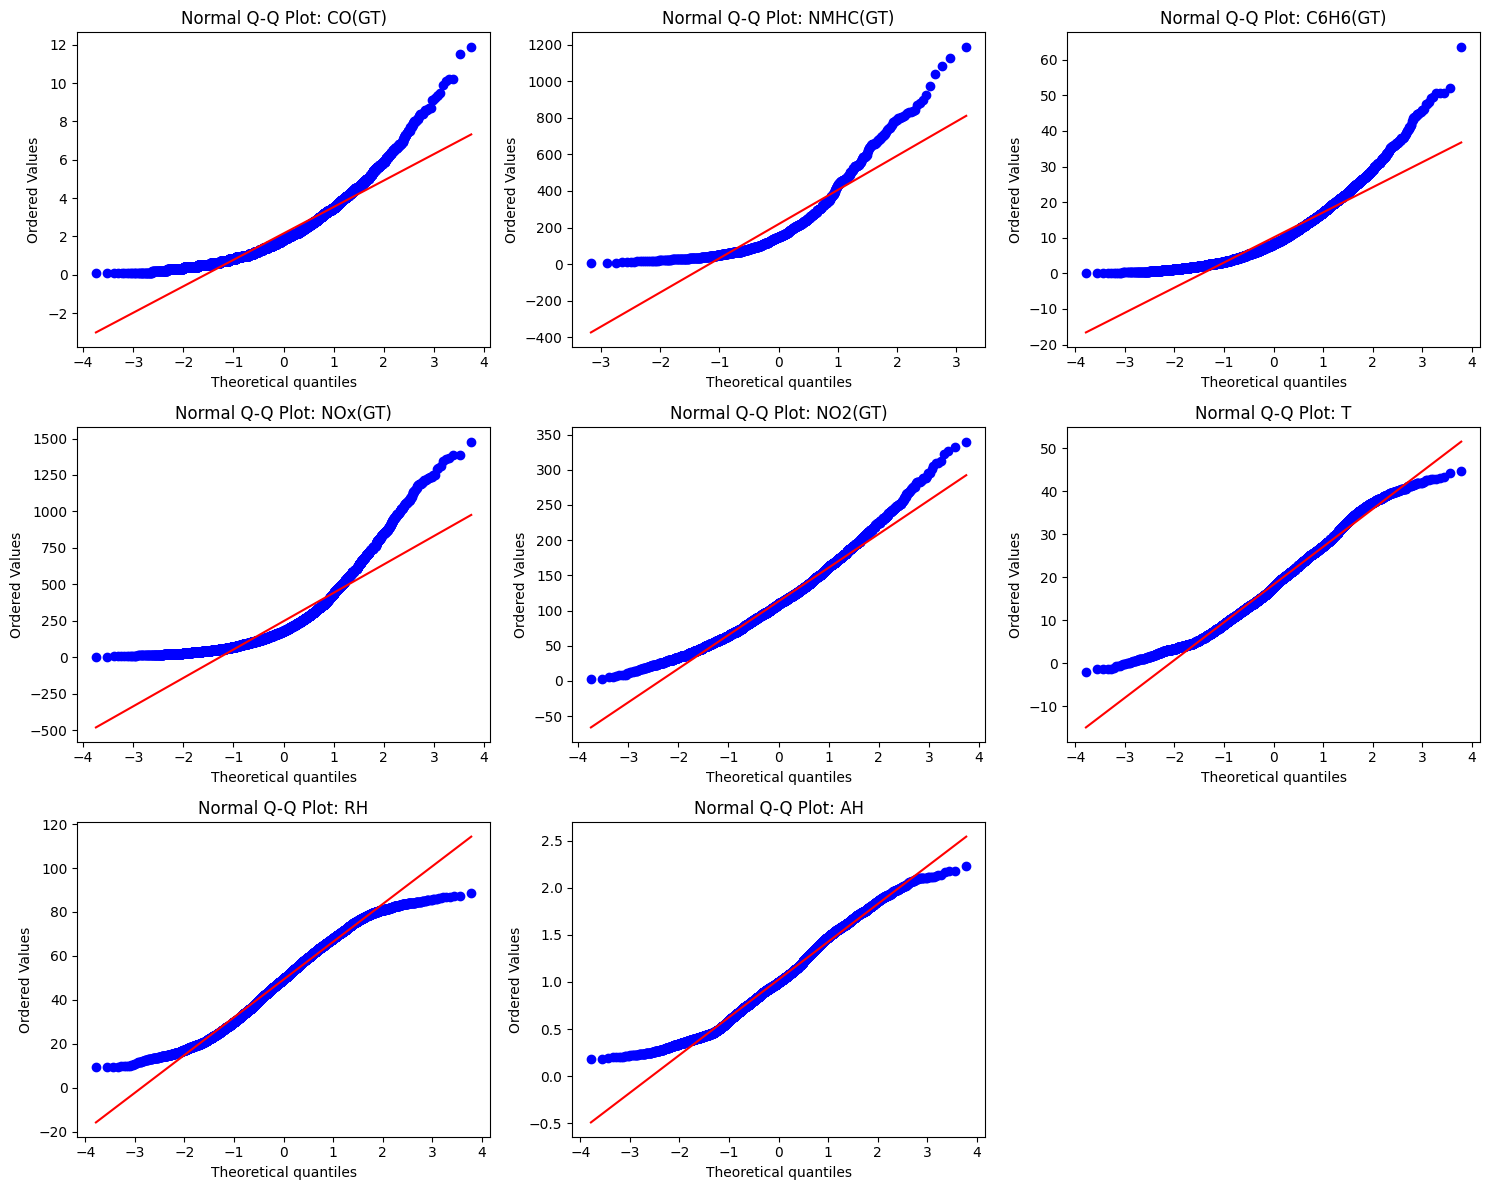

In [18]:
print("Name: prakhar tyagi")
print("URN: 2481010")

from scipy import stats

qq_columns = pollutant_columns + weather_columns
n_columns = 3
n_rows = int(np.ceil(len(qq_columns) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(15, 4 * n_rows))
axes = np.asarray(axes).ravel()

for axis, column in zip(axes, qq_columns):
    values = df[column].dropna()
    stats.probplot(values, dist="norm", plot=axis)
    axis.set_title(f"Normal Q-Q Plot: {column}")

for axis in axes[len(qq_columns):]:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 6. Time Features and Coverage

Air-quality records are hourly. Extracting year, month, day, hour, and weekday makes seasonal and daily patterns easier to compare.

In [19]:
print("Name: prakhar tyagi")
print("URN: 2481010")

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["month_name"] = df["datetime"].dt.month_name()
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()

print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Years covered:", sorted(df["year"].dropna().unique().tolist()))
print("Records per year:")
display(df["year"].value_counts().sort_index().to_frame("records"))

print("Hourly coverage check:")
hourly_counts = df.set_index("datetime").resample("h").size()
print("Expected hourly periods:", len(hourly_counts))
print("Periods with records:", (hourly_counts > 0).sum())

Name: prakhar tyagi
URN: 2481010
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Years covered: [2004, 2005]
Records per year:


,records
year,
2004,7110
2005,2247


Hourly coverage check:
Expected hourly periods: 9357
Periods with records: 9357


## 7. Univariate EDA: Distributions

Histograms show concentration, skewness, and the effect of missing measurements. Boxplots provide a compact view of spread and possible extreme values.

Name: prakhar tyagi
URN: 2481010


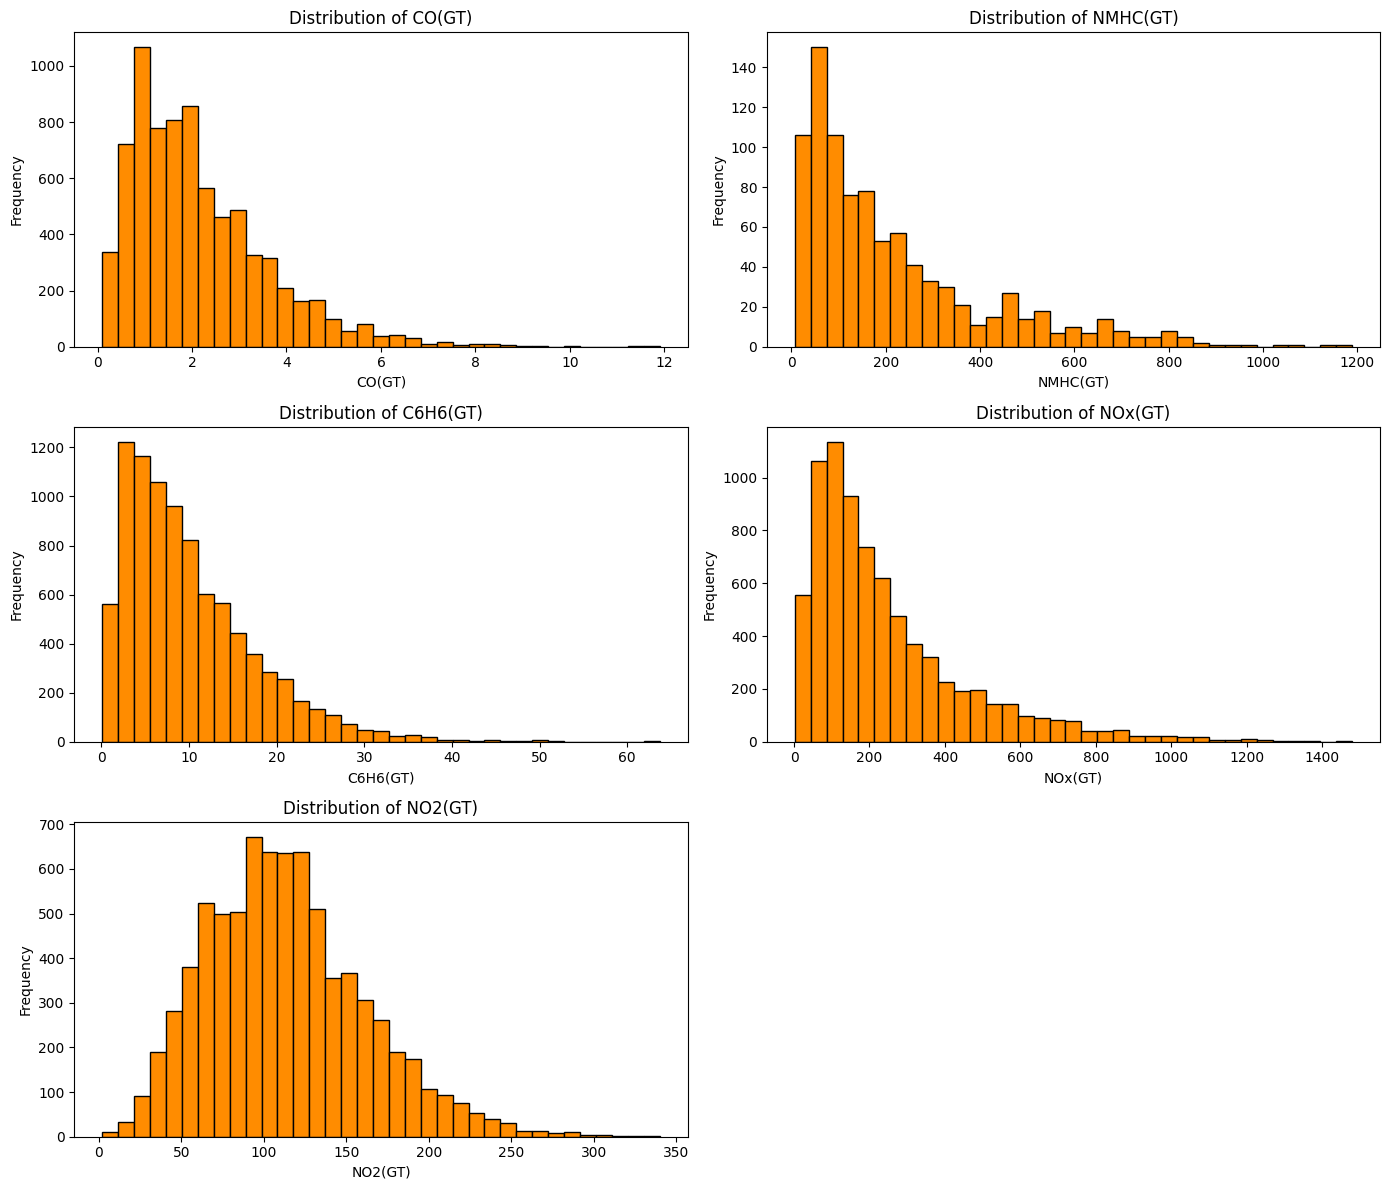

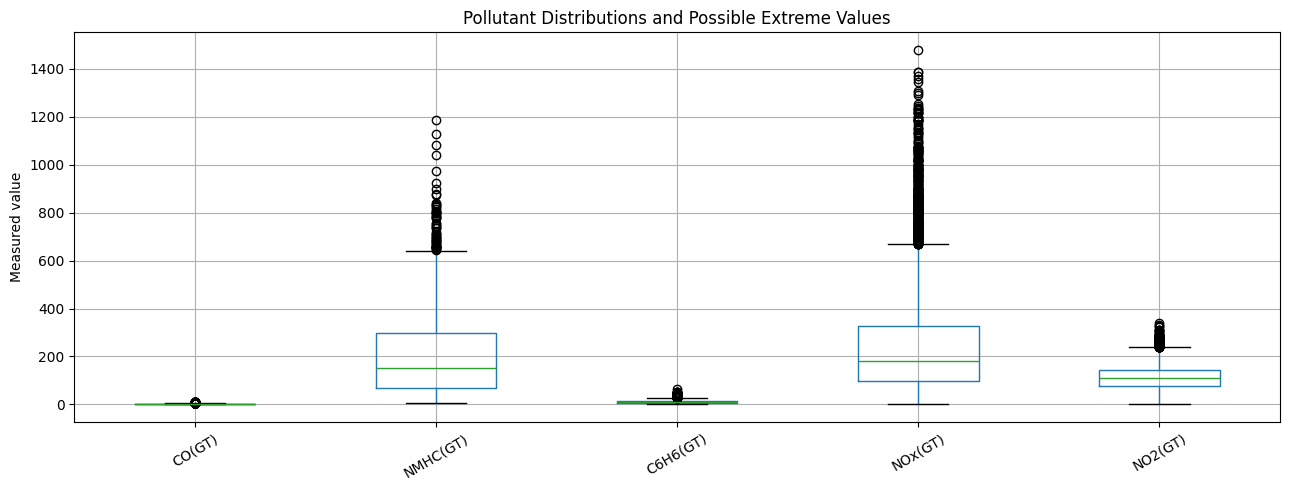

In [20]:
print("Name: prakhar tyagi")
print("URN: 2481010")

pollutant_columns = [
    "CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"
]
sensor_columns = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)"
]
weather_columns = ["T", "RH", "AH"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for axis, column in zip(axes.flat, pollutant_columns):
    axis.hist(df[column].dropna(), bins=35, edgecolor="black", color="darkorange")
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Frequency")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 5))
df[pollutant_columns].boxplot(rot=30)
plt.title("Pollutant Distributions and Possible Extreme Values")
plt.ylabel("Measured value")
plt.tight_layout()
plt.show()

## 8. Temporal EDA

The following plots compare hourly pollution behavior and monthly averages. Averaging by time period makes long records easier to interpret.

Name: prakhar tyagi
URN: 2481010


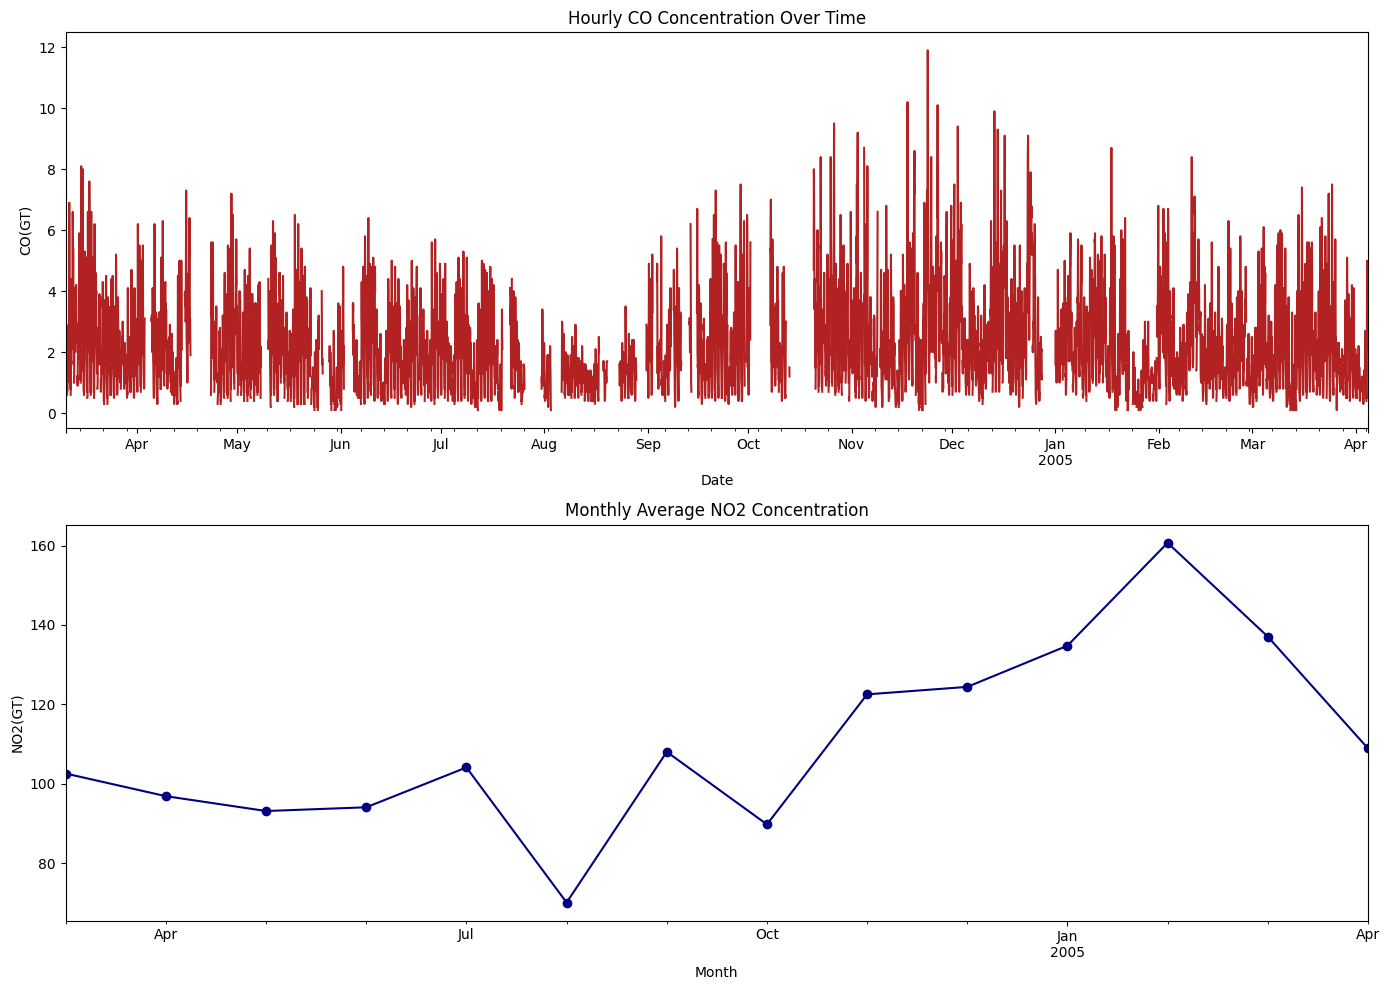

In [21]:
print("Name: prakhar tyagi")
print("URN: 2481010")

hourly_means = df.set_index("datetime")[pollutant_columns].resample("h").mean()
monthly_means = df.groupby(["year", "month"], as_index=False)[pollutant_columns].mean()
monthly_means["period"] = pd.to_datetime(
    monthly_means["year"].astype(str) + "-" + monthly_means["month"].astype(str) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
hourly_means["CO(GT)"].plot(ax=axes[0], color="firebrick")
axes[0].set_title("Hourly CO Concentration Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("CO(GT)")

monthly_means.plot(x="period", y="NO2(GT)", ax=axes[1], marker="o", color="navy", legend=False)
axes[1].set_title("Monthly Average NO2 Concentration")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("NO2(GT)")

plt.tight_layout()
plt.show()

## 9. Diurnal Patterns

Traffic and atmospheric chemistry can produce different pollution levels at different hours. Grouping by hour allows a simple comparison of the daily cycle.

Name: prakhar tyagi
URN: 2481010


,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT)
hour,,,,,
0,1.79,103.13,7.68,190.42,103.32
1,1.47,76.97,5.99,157.33,90.50
2,1.10,61.87,4.38,118.58,75.44
3,0.89,52.97,3.38,114.58,80.12
4,0.76,40.19,2.92,81.15,58.62
5,0.71,40.08,3.07,86.80,59.61
6,0.92,71.45,4.76,125.69,71.74
7,1.81,235.61,10.40,224.63,94.71
8,2.82,421.55,15.89,344.72,121.27


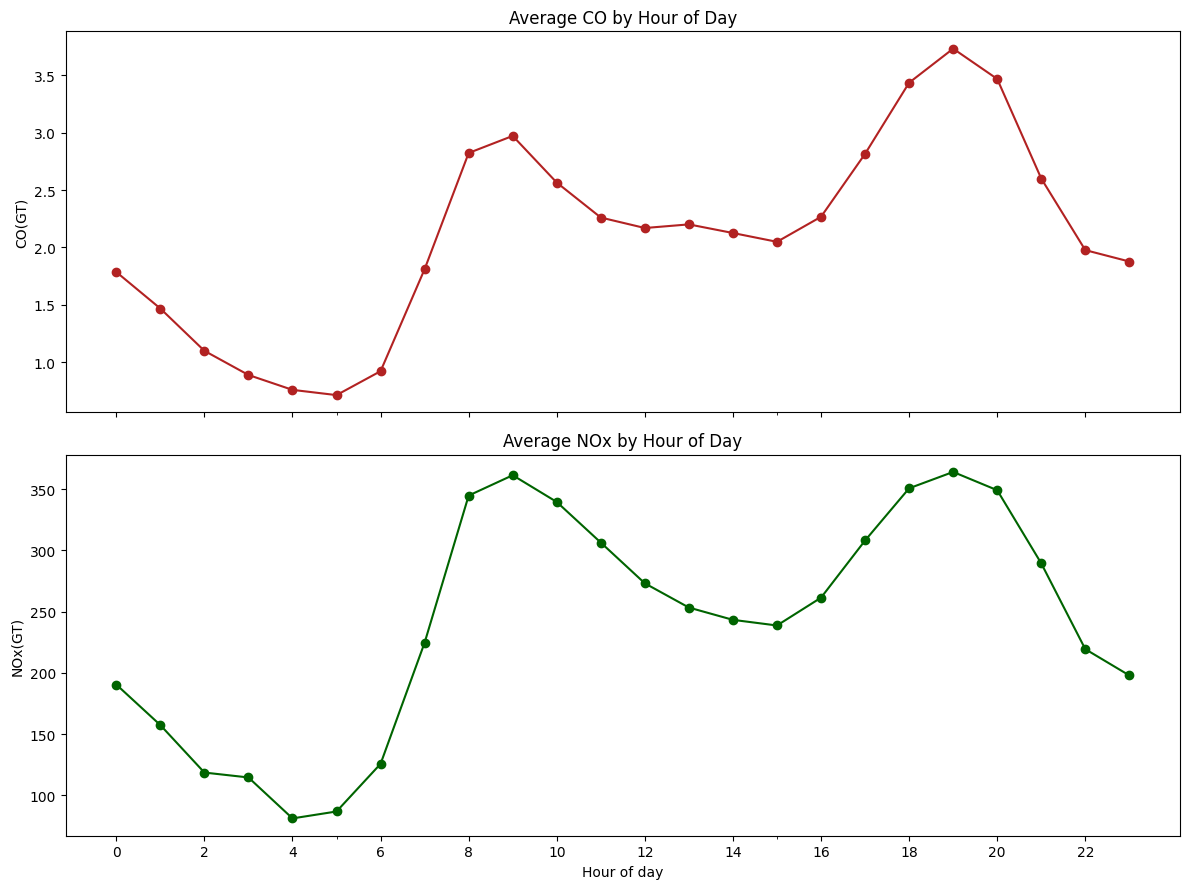

In [22]:
print("Name: prakhar tyagi")
print("URN: 2481010")

hourly_profile = df.groupby("hour")[pollutant_columns].mean()
display(hourly_profile.round(2))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
hourly_profile["CO(GT)"].plot(ax=axes[0], marker="o", color="firebrick")
axes[0].set_title("Average CO by Hour of Day")
axes[0].set_ylabel("CO(GT)")

hourly_profile["NOx(GT)"].plot(ax=axes[1], marker="o", color="darkgreen")
axes[1].set_title("Average NOx by Hour of Day")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("NOx(GT)")

plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

## 10. Bivariate EDA: Pollution and Weather

Scatter plots help inspect relationships between pollutant measurements and weather variables. A visible pattern is an association, not proof of causation.

Name: prakhar tyagi
URN: 2481010


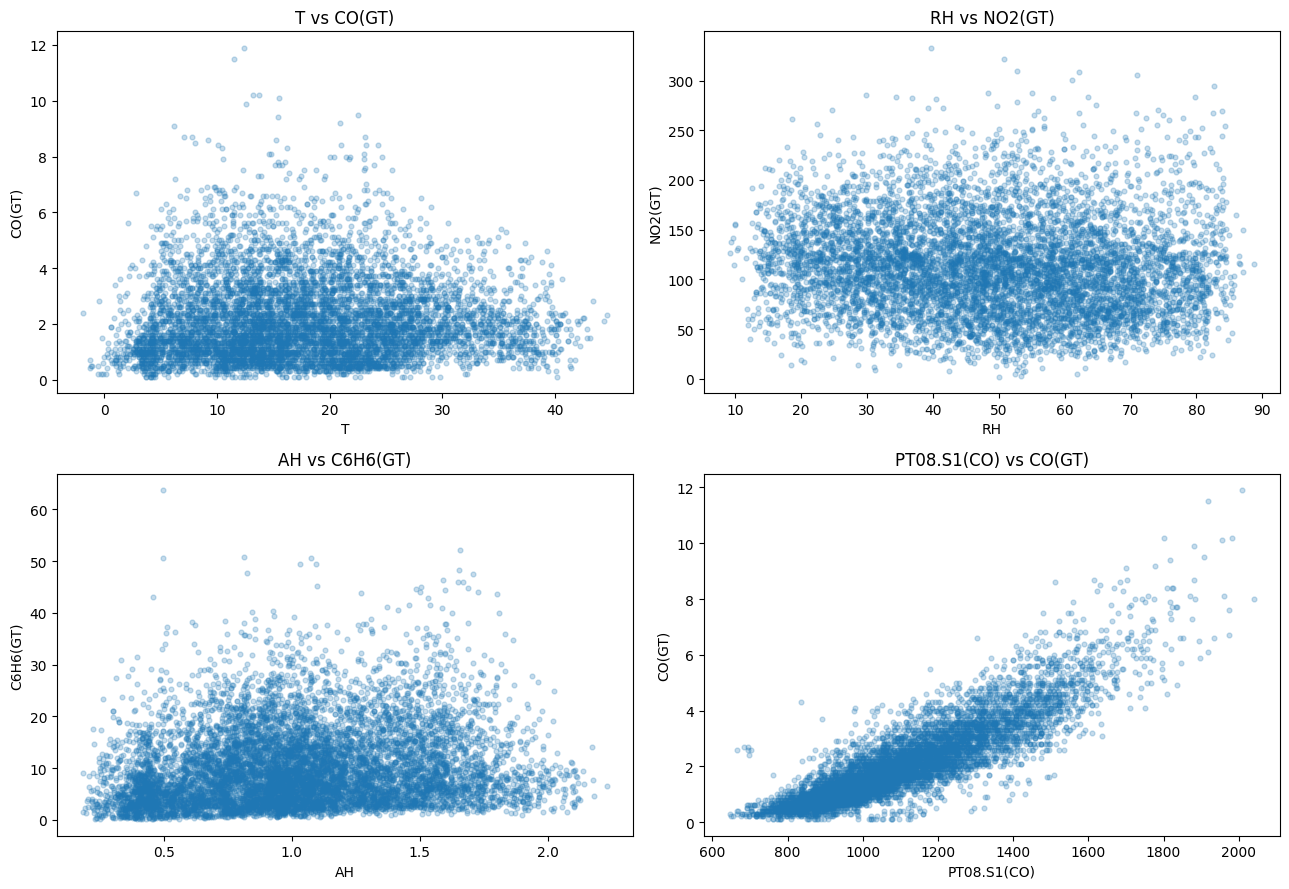

Selected Pearson correlations:


,T,CO(GT),RH,NO2(GT),AH,C6H6(GT),PT08.S1(CO),CO(GT)
T,1.00,0.02,-0.58,-0.19,0.66,0.20,0.05,0.02
CO(GT),0.02,1.00,0.05,0.68,0.05,0.93,0.88,1.00
RH,-0.58,0.05,1.00,-0.09,0.17,-0.06,0.12,0.05
NO2(GT),-0.19,0.68,-0.09,1.00,-0.34,0.61,0.64,0.68
AH,0.66,0.05,0.17,-0.34,1.00,0.17,0.14,0.05
C6H6(GT),0.20,0.93,-0.06,0.61,0.17,1.00,0.88,0.93
PT08.S1(CO),0.05,0.88,0.12,0.64,0.14,0.88,1.00,0.88
CO(GT),0.02,1.00,0.05,0.68,0.05,0.93,0.88,1.00


In [23]:
print("Name: prakhar tyagi")
print("URN: 2481010")

relationships = [
    ("T", "CO(GT)"),
    ("RH", "NO2(GT)"),
    ("AH", "C6H6(GT)"),
    ("PT08.S1(CO)", "CO(GT)")
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, (x_column, y_column) in zip(axes.flat, relationships):
    valid = df[[x_column, y_column]].dropna()
    axis.scatter(valid[x_column], valid[y_column], alpha=0.25, s=12)
    axis.set_title(f"{x_column} vs {y_column}")
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)
plt.tight_layout()
plt.show()

print("Selected Pearson correlations:")
display(df[[x for pair in relationships for x in pair]].corr().round(3))

## 11. Grouped Analysis by Month and Weekday

Grouped means provide interpretable comparisons across calendar periods. They should be read together with record counts because unequal coverage can affect averages.

Name: prakhar tyagi
URN: 2481010
Average pollution by month:


CO(GT)       NMHC(GT)       C6H6(GT)       NOx(GT)       NO2(GT)      
             mean count     mean count     mean count    mean count    mean count
month_name                                                                       
March        2.14  1216   171.60   407     9.22  1253  243.18  1221  123.29  1221
April        2.14   580   256.67   506     9.71   780  145.64   573   98.71   573
May          1.94   592   275.00     1    10.22   730  122.13   598   93.15   598
June         1.90   644      NaN     0    10.60   682  122.06   649   94.08   648
July         1.78   558      NaN     0    10.60   743  126.75   712  104.12   711
August       1.28   477      NaN     0     6.99   695   75.87   502   70.10   501
September    2.16   556      NaN     0    11.55   702  280.57   444  108.05   444
October      2.72   393      NaN     0    13.53   743  338.01   387   89.78   387
November     2.69   679      NaN     0    12.51   720  424.19   658  122.53   658
December     2.75   640      NaN     0     9.50   664  417.12   622  124.41   622
January      2.14   676      NaN     0     9.02   683  349.82   710  134.78   710
February     2.10   663      NaN     0     7.50   596  315.04   642  160.69   642

Average pollution by weekday:


,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT)
weekday,,,,,
Monday,2.02,180.11,9.96,234.93,110.30
Tuesday,2.38,233.58,11.68,267.67,117.39
Wednesday,2.40,219.56,11.40,270.43,120.01
Thursday,2.46,278.80,11.53,282.60,120.84
Friday,2.54,287.30,11.73,284.51,123.45
Saturday,1.86,164.56,8.51,224.49,107.57
Sunday,1.44,99.11,6.05,162.00,91.66


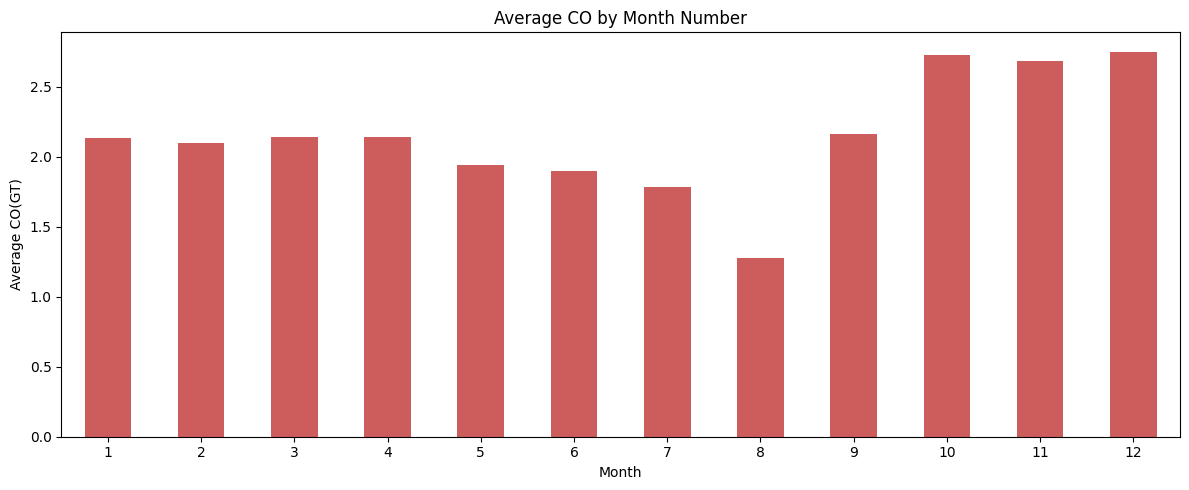

In [24]:
print("Name: prakhar tyagi")
print("URN: 2481010")

monthly_pollution = df.groupby("month_name", sort=False)[pollutant_columns].agg(["mean", "count"])
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_pollution = df.groupby("weekday")[pollutant_columns].mean().reindex(weekday_order)

print("Average pollution by month:")
display(monthly_pollution.round(2))

print("Average pollution by weekday:")
display(weekday_pollution.round(2))

plt.figure(figsize=(12, 5))
df.groupby("month")["CO(GT)"].mean().plot(kind="bar", color="indianred")
plt.title("Average CO by Month Number")
plt.xlabel("Month")
plt.ylabel("Average CO(GT)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Outlier Analysis with the IQR Rule

For each pollutant, possible outliers are values below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$. These observations are flagged for investigation, not automatically deleted.

In [25]:
print("Name: prakhar tyagi")
print("URN: 2481010")

outlier_rows = []

for column in pollutant_columns + weather_columns:
    series = df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

    outlier_rows.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Possible Outliers": outlier_count,
        "Outlier Percentage": outlier_count / len(series) * 100
    })

outlier_report = pd.DataFrame(outlier_rows).set_index("Feature")
display(outlier_report.round(2))

Name: prakhar tyagi
URN: 2481010


,Q1,Q3,IQR,Lower Bound,Upper Bound,Possible Outliers,Outlier Percentage
Feature,,,,,,,
CO(GT),1.10,2.90,1.80,-1.60,5.60,215,2.80
NMHC(GT),67.00,297.00,230.00,-278.00,642.00,55,6.02
C6H6(GT),4.40,14.00,9.60,-10.00,28.40,228,2.54
NOx(GT),98.00,326.00,228.00,-244.00,668.00,435,5.64
NO2(GT),78.00,142.00,64.00,-18.00,238.00,107,1.39
T,11.80,24.40,12.60,-7.10,43.30,3,0.03
RH,35.80,62.50,26.70,-4.25,102.55,0,0.00
AH,0.74,1.31,0.58,-0.13,2.18,2,0.02


# Part M — Complete Outlier Detection

One method is not enough for every distribution. IQR is robust and easy to explain, z-scores work best for approximately symmetric data, modified z-scores use the median and MAD, percentile rules flag tail observations, and rolling residuals help identify unusual time points.

In [26]:
print("Name: prakhar tyagi")
print("URN: 2481010")

outlier_methods = []

for column in analysis_columns:
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_mask = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)

    mean, std = values.mean(), values.std()
    z_mask = (values - mean).abs() > 3 * std

    median = values.median()
    mad = np.median(np.abs(values - median))
    modified_z = 0.6745 * (values - median) / mad if mad else pd.Series(0, index=values.index)
    modified_z_mask = modified_z.abs() > 3.5

    lower_percentile, upper_percentile = values.quantile([0.01, 0.99])
    percentile_mask = (values < lower_percentile) | (values > upper_percentile)

    outlier_methods.append({
        "Feature": column,
        "IQR count": int(iqr_mask.sum()),
        "IQR (%)": iqr_mask.mean() * 100,
        "Z-score count": int(z_mask.sum()),
        "Z-score (%)": z_mask.mean() * 100,
        "Modified Z count": int(modified_z_mask.sum()),
        "Modified Z (%)": modified_z_mask.mean() * 100,
        "1%-99% count": int(percentile_mask.sum()),
        "1%-99% (%)": percentile_mask.mean() * 100
    })

outlier_comparison = pd.DataFrame(outlier_methods).set_index("Feature")
display(outlier_comparison.round(2))

Name: prakhar tyagi
URN: 2481010


,IQR count,IQR (%),Z-score count,Z-score (%),Modified Z count,Modified Z (%),1%-99% count,1%-99% (%)
Feature,,,,,,,,
CO(GT),215,2.80,102,1.33,165,2.15,104,1.36
NMHC(GT),55,6.02,11,1.20,57,6.24,18,1.97
C6H6(GT),228,2.54,118,1.31,146,1.62,167,1.86
NOx(GT),435,5.64,138,1.79,379,4.91,142,1.84
NO2(GT),107,1.39,48,0.62,27,0.35,151,1.96
PT08.S1(CO),118,1.31,60,0.67,39,0.43,178,1.98
PT08.S2(NMHC),65,0.72,37,0.41,13,0.14,176,1.96
PT08.S3(NOx),241,2.68,109,1.21,108,1.20,178,1.98
PT08.S4(NO2),97,1.08,38,0.42,15,0.17,180,2.00


## Time-Series Outliers Using a Rolling Baseline

A value can be normal globally but unusual for its local time period. This rolling analysis compares CO with a 24-hour rolling median and rolling MAD.

Name: prakhar tyagi
URN: 2481010
Rolling CO anomalies: 111
Rolling anomaly percentage: 1.45 %


,CO,Rolling median,Rolling modified z,Rolling outlier
datetime,,,,
2004-03-11 19:00:00,6.90,1.90,4.22,True
2004-03-14 20:00:00,5.90,2.20,3.57,True
2004-03-21 18:00:00,3.80,1.70,3.54,True
2004-03-21 20:00:00,4.30,1.80,4.22,True
2004-03-25 19:00:00,5.20,1.80,3.67,True
2004-03-29 08:00:00,4.10,1.45,5.96,True
2004-04-01 08:00:00,6.20,1.70,3.79,True
2004-04-08 08:00:00,5.10,2.40,3.64,True
2004-04-11 12:00:00,2.60,1.10,4.05,True


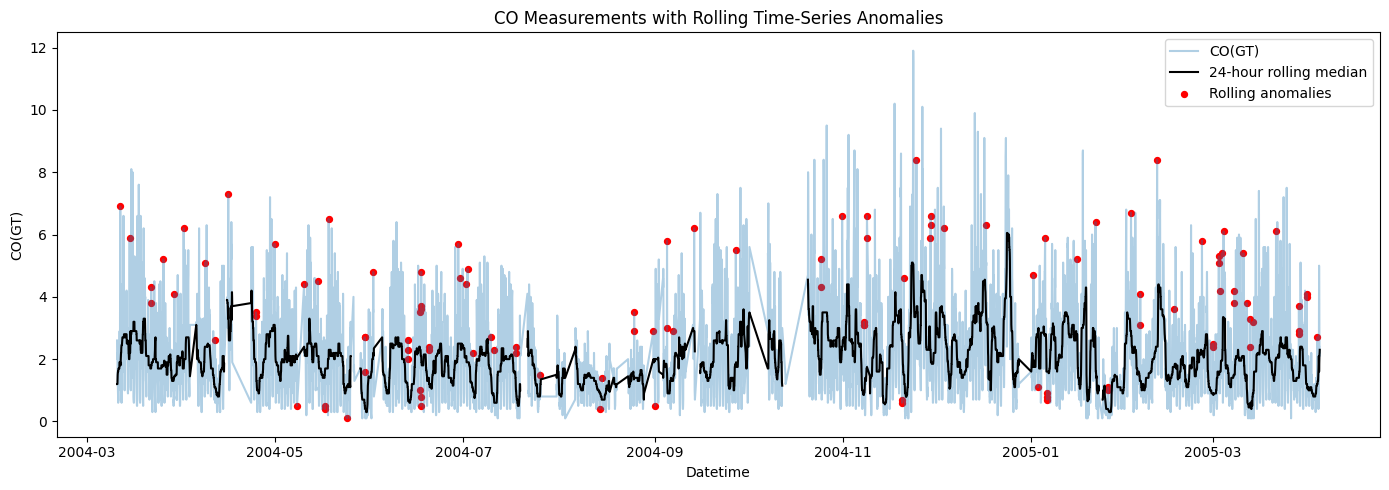

In [27]:
print("Name: prakhar tyagi")
print("URN: 2481010")

co_series = df.set_index("datetime")["CO(GT)"].dropna().sort_index()
rolling_median = co_series.rolling("24h", center=True, min_periods=12).median()
rolling_mad = (
    co_series.subtract(rolling_median).abs()
    .rolling("24h", center=True, min_periods=12)
    .median()
)
rolling_modified_z = 0.6745 * co_series.subtract(rolling_median) / rolling_mad.replace(0, np.nan)
rolling_outliers = rolling_modified_z.abs() > 3.5

print("Rolling CO anomalies:", int(rolling_outliers.sum()))
print("Rolling anomaly percentage:", round(rolling_outliers.mean() * 100, 2), "%")

time_outlier_table = pd.DataFrame({
    "CO": co_series,
    "Rolling median": rolling_median,
    "Rolling modified z": rolling_modified_z,
    "Rolling outlier": rolling_outliers
}).dropna()
display(time_outlier_table[time_outlier_table["Rolling outlier"]].head(10))

plt.figure(figsize=(14, 5))
plt.plot(co_series.index, co_series, alpha=0.35, label="CO(GT)")
plt.plot(rolling_median.index, rolling_median, color="black", label="24-hour rolling median")
plt.scatter(
    time_outlier_table.index[time_outlier_table["Rolling outlier"]],
    time_outlier_table.loc[time_outlier_table["Rolling outlier"], "CO"],
    color="red", s=18, label="Rolling anomalies"
)
plt.title("CO Measurements with Rolling Time-Series Anomalies")
plt.xlabel("Datetime")
plt.ylabel("CO(GT)")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Multivariate EDA: Correlation Matrix

The correlation matrix summarizes linear associations among pollutants, sensor readings, and weather variables. Correlation is descriptive and does not establish causation.

Name: prakhar tyagi
URN: 2481010


,CO(GT),NMHC(GT),C6H6(GT),NOx(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.00,0.89,0.93,0.80,0.68,0.88,0.92,-0.70,0.63,0.85,0.02,0.05,0.05
NMHC(GT),0.89,1.00,0.90,0.81,0.73,0.79,0.88,-0.77,0.85,0.77,0.39,-0.19,0.27
C6H6(GT),0.93,0.90,1.00,0.72,0.61,0.88,0.98,-0.74,0.77,0.87,0.20,-0.06,0.17
NOx(GT),0.80,0.81,0.72,1.00,0.76,0.71,0.70,-0.66,0.23,0.79,-0.27,0.22,-0.15
NO2(GT),0.68,0.73,0.61,0.76,1.00,0.64,0.65,-0.65,0.16,0.71,-0.19,-0.09,-0.34
PT08.S1(CO),0.88,0.79,0.88,0.71,0.64,1.00,0.89,-0.77,0.68,0.90,0.05,0.11,0.14
PT08.S2(NMHC),0.92,0.88,0.98,0.70,0.65,0.89,1.00,-0.80,0.78,0.88,0.24,-0.09,0.19
PT08.S3(NOx),-0.70,-0.77,-0.74,-0.66,-0.65,-0.77,-0.80,1.00,-0.54,-0.80,-0.15,-0.06,-0.23
PT08.S4(NO2),0.63,0.85,0.77,0.23,0.16,0.68,0.78,-0.54,1.00,0.59,0.56,-0.03,0.63
PT08.S5(O3),0.85,0.77,0.87,0.79,0.71,0.90,0.88,-0.80,0.59,1.00,-0.03,0.12,0.07


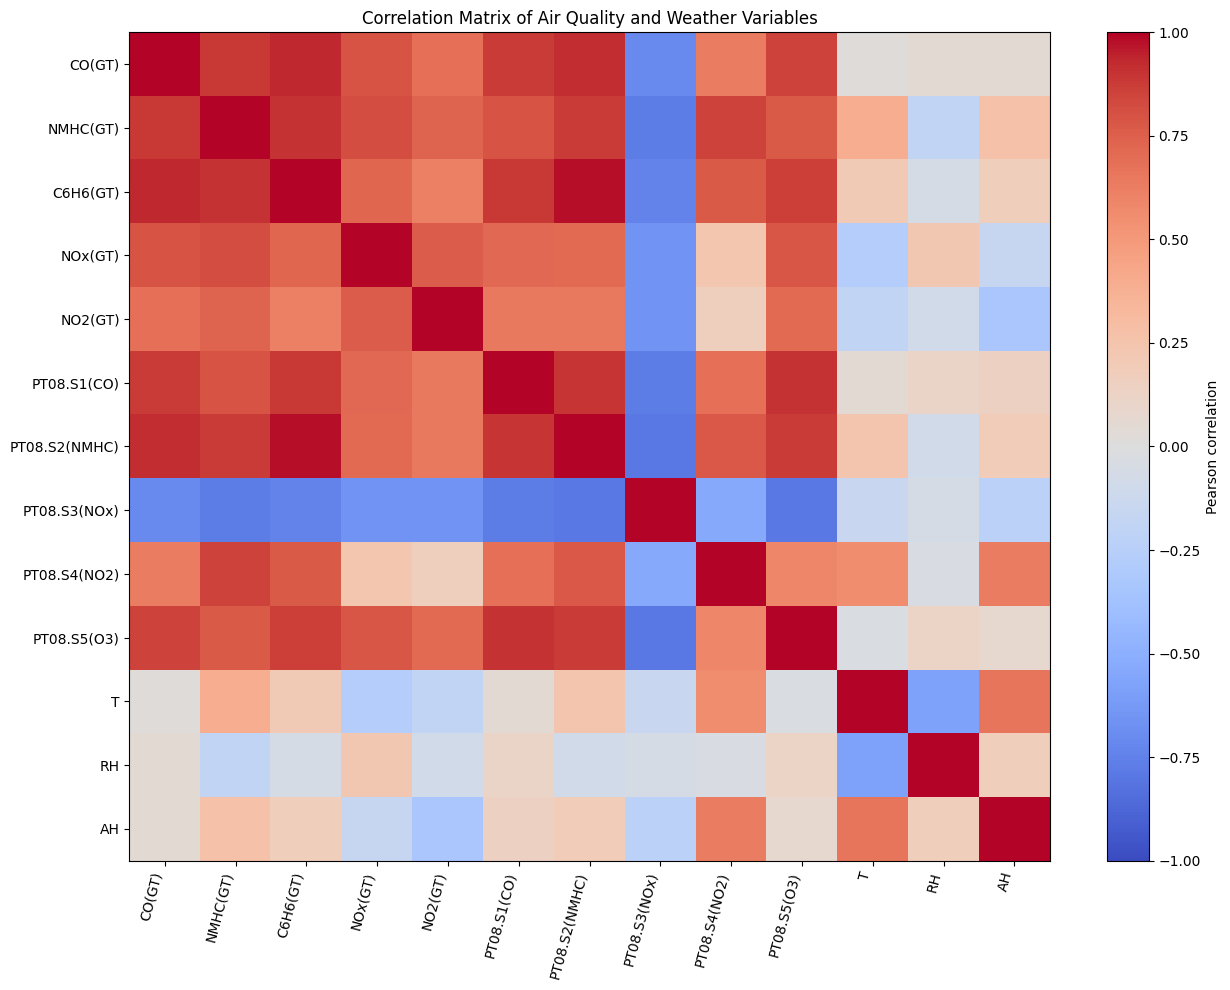

Strongest correlations with CO(GT):


,correlation
C6H6(GT),0.93
PT08.S2(NMHC),0.92
NMHC(GT),0.89
PT08.S1(CO),0.88
PT08.S5(O3),0.85
NOx(GT),0.80
PT08.S3(NOx),-0.70
NO2(GT),0.68


In [28]:
print("Name: prakhar tyagi")
print("URN: 2481010")

analysis_columns = pollutant_columns + sensor_columns + weather_columns
correlation_matrix = df[analysis_columns].corr()
display(correlation_matrix.round(2))

plt.figure(figsize=(13, 10))
image = plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(image, label="Pearson correlation")
plt.xticks(range(len(analysis_columns)), analysis_columns, rotation=75, ha="right")
plt.yticks(range(len(analysis_columns)), analysis_columns)
plt.title("Correlation Matrix of Air Quality and Weather Variables")
plt.tight_layout()
plt.show()

print("Strongest correlations with CO(GT):")
co_correlations = correlation_matrix["CO(GT)"].drop("CO(GT)").sort_values(key=abs, ascending=False)
display(co_correlations.head(8).to_frame("correlation"))

Name: Prakhar Tyagi
URN : 2481010
section: b 
lab Subject : Introduction to Machine learning 
Experiment 3


In [29]:
print("Name: prakhar tyagi")
print("URN: 2481010")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Name: prakhar tyagi
URN: 2481010
Libraries imported successfully.


**Load the dataset**


In [30]:
print("Name: prakhar tyagi")
print("URN: 2481010")

import numpy as np
import pandas as pd

raw = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
raw = raw.dropna(axis=1, how="all").replace(-200, np.nan)
raw["datetime"] = pd.to_datetime(
    raw["Date"] + " " + raw["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)
raw = raw.dropna(subset=["datetime"]).drop_duplicates().reset_index(drop=True)

print("Shape:", raw.shape)
display(raw.head())

Name: prakhar tyagi
URN: 2481010
Shape: (9357, 16)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime
0,10/03/2004,18.00.00,2.60,"1,360.00",150.00,11.90,"1,046.00",166.00,"1,056.00",113.00,"1,692.00","1,268.00",13.60,48.90,0.76,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.00,"1,292.00",112.00,9.40,955.00,103.00,"1,174.00",92.00,"1,559.00",972.00,13.30,47.70,0.73,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.20,"1,402.00",88.00,9.00,939.00,131.00,"1,140.00",114.00,"1,555.00","1,074.00",11.90,54.00,0.75,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.20,"1,376.00",80.00,9.20,948.00,172.00,"1,092.00",122.00,"1,584.00","1,203.00",11.00,60.00,0.79,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.60,"1,272.00",51.00,6.50,836.00,131.00,"1,205.00",116.00,"1,490.00","1,110.00",11.20,59.60,0.79,2004-03-10 22:00:00


**select the feature**

In [31]:
print("Name: prakhar tyagi")
print("URN: 2481010")

TARGET = "CO(GT)"

FEATURES = [
    "PT08.S1(CO)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "T", "RH", "AH"
]

data = raw[FEATURES + [TARGET]].dropna(subset=[TARGET]).reset_index(drop=True)
X = data[FEATURES]
y = data[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

Name: prakhar tyagi
URN: 2481010
X shape: (7674, 11)
y shape: (7674,)


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,"1,360.00",11.90,"1,046.00",166.00,"1,056.00",113.00,"1,692.00","1,268.00",13.60,48.90,0.76
1,"1,292.00",9.40,955.00,103.00,"1,174.00",92.00,"1,559.00",972.00,13.30,47.70,0.73
2,"1,402.00",9.00,939.00,131.00,"1,140.00",114.00,"1,555.00","1,074.00",11.90,54.00,0.75
3,"1,376.00",9.20,948.00,172.00,"1,092.00",122.00,"1,584.00","1,203.00",11.00,60.00,0.79
4,"1,272.00",6.50,836.00,131.00,"1,205.00",116.00,"1,490.00","1,110.00",11.20,59.60,0.79


In [ ]:
print("Name: prakhar tyagi")
print("URN: 2481010")

print("Missing before:\n", X.isna().sum())

X_clean = X.copy()
for col in X_clean.columns:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

print("\nMissing after:\n", X_clean.isna().sum())
print("\nFinal shape:", X_clean.shape)
display(X_clean.describe())

Missing before:
 PT08.S1(CO)      330
C6H6(GT)         330
PT08.S2(NMHC)    330
NOx(GT)          413
PT08.S3(NOx)     330
NO2(GT)          416
PT08.S4(NO2)     330
PT08.S5(O3)      330
T                330
RH               330
AH               330
dtype: int64

Missing after:
 PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Final shape: (7674, 11)


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000
mean,1109.050691,10.199375,945.985536,251.691165,825.547433,114.551082,1444.849361,1041.211754,17.732995,49.070394,0.988174
std,214.048885,7.288206,259.763178,210.022201,251.152318,46.930717,342.727887,396.900917,8.671809,17.072230,0.391242
min,647.000000,0.200000,387.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,953.000000,4.800000,752.000000,107.000000,657.000000,82.000000,1215.250000,759.000000,11.500000,36.200000,0.714375
50%,1075.000000,8.500000,919.000000,188.000000,795.000000,110.000000,1447.000000,990.000000,16.900000,49.300000,0.959700
75%,1235.000000,14.000000,1116.750000,326.000000,949.000000,141.000000,1659.000000,1287.000000,23.500000,61.800000,1.235200
max,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600


Name: prakhar tyagi
URN: 2481010
Correlation with CO(GT):
CO(GT)           1.00
C6H6(GT)         0.93
PT08.S2(NMHC)    0.92
PT08.S1(CO)      0.88
PT08.S5(O3)      0.85
NOx(GT)          0.80
NO2(GT)          0.68
PT08.S4(NO2)     0.63
RH               0.05
AH               0.05
T                0.02
PT08.S3(NOx)    -0.70
Name: CO(GT), dtype: float64


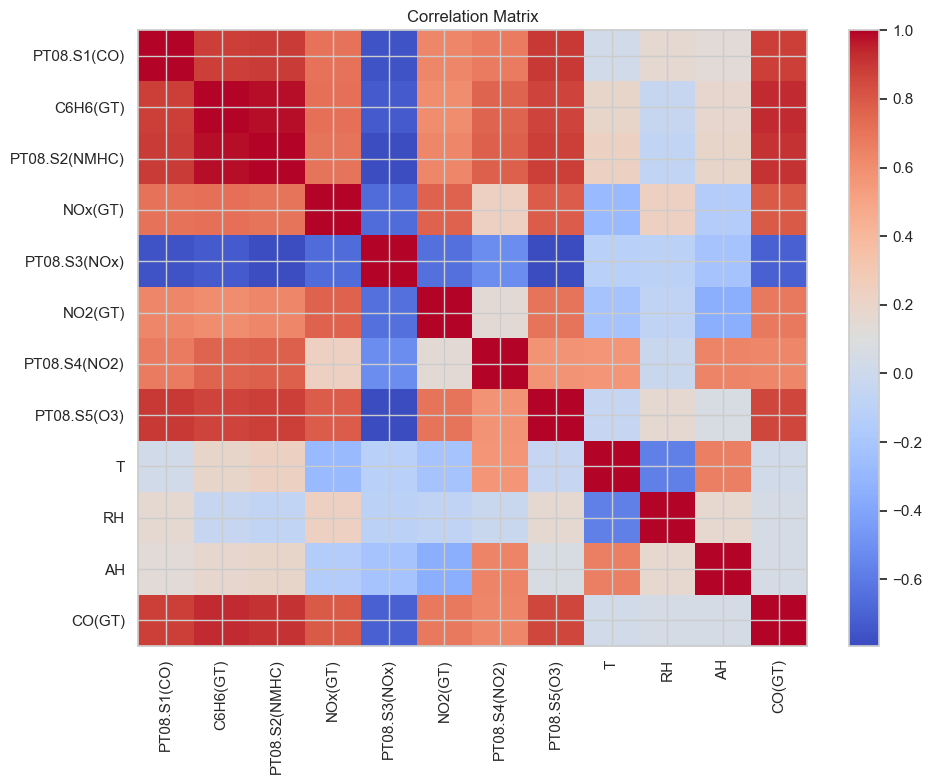

In [32]:
print("Name: prakhar tyagi")
print("URN: 2481010")

import matplotlib.pyplot as plt

corr = data.corr()
print("Correlation with CO(GT):")
print(corr["CO(GT)"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [35]:
print("Name: prakhar tyagi")
print("URN: 2481010")

X_clean = X.copy()
for col in X_clean.columns:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

X = X_clean
y = data[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

Name: prakhar tyagi
URN: 2481010
X shape: (7674, 11)
y shape: (7674,)


In [36]:
print("Name: prakhar tyagi")
print("URN: 2481010")

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Name: prakhar tyagi
URN: 2481010
Train size: (6139, 11)
Test size: (1535, 11)


In [37]:
print("Name: prakhar tyagi")
print("URN: 2481010")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2:  ", r2_score(y_test, y_pred))

# Coefficients
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nCoefficients:\n", coef_df)

Name: prakhar tyagi
URN: 2481010
MAE:  0.3080956236912925
MSE:  0.23171568728803396
RMSE: 0.4813685566050549
R2:   0.8887521250454486

Coefficients:
           Feature  Coefficient
0     PT08.S1(CO)         0.00
1        C6H6(GT)         0.08
2   PT08.S2(NMHC)        -0.00
3         NOx(GT)         0.00
4    PT08.S3(NOx)         0.00
5         NO2(GT)         0.00
6    PT08.S4(NO2)         0.00
7     PT08.S5(O3)        -0.00
8               T        -0.03
9              RH        -0.01
10             AH        -0.13


In [38]:
print("Name: prakhar tyagi")
print("URN: 2481010")

y_pred = model.predict(X_test)

pred_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
print(pred_df.head(10))

Name: prakhar tyagi
URN: 2481010
   Actual  Predicted
0    7.10       4.60
1    0.90       1.05
2    3.80       3.40
3    2.30       2.07
4    0.90       1.10
5    2.20       2.58
6    5.60       3.85
7    1.60       1.37
8    3.10       3.05
9    3.30       2.82


In [39]:
print("Name: prakhar tyagi")
print("URN: 2481010")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Name: prakhar tyagi
URN: 2481010
MAE  : 0.3081
MSE  : 0.2317
RMSE : 0.4814
R²   : 0.8888


Name: prakhar tyagi
URN: 2481010


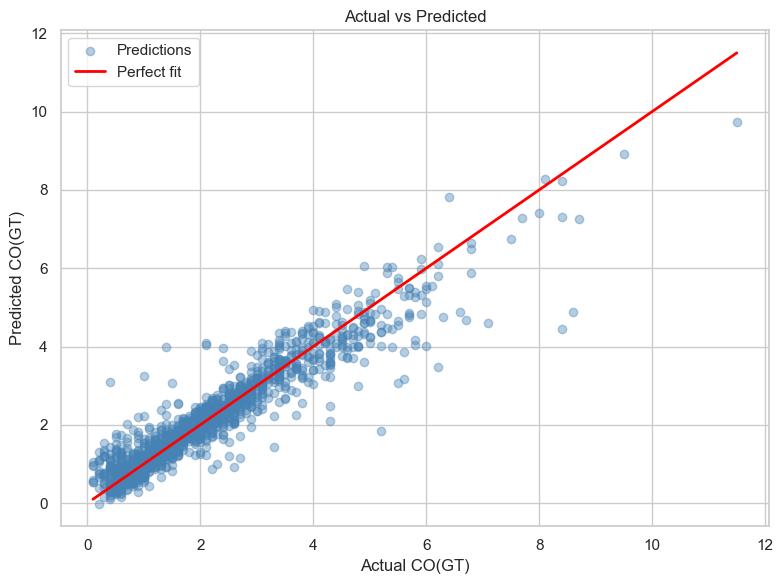

In [40]:
print("Name: prakhar tyagi")
print("URN: 2481010")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue", label="Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect fit")
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

Name: prakhar tyagi
URN: 2481010


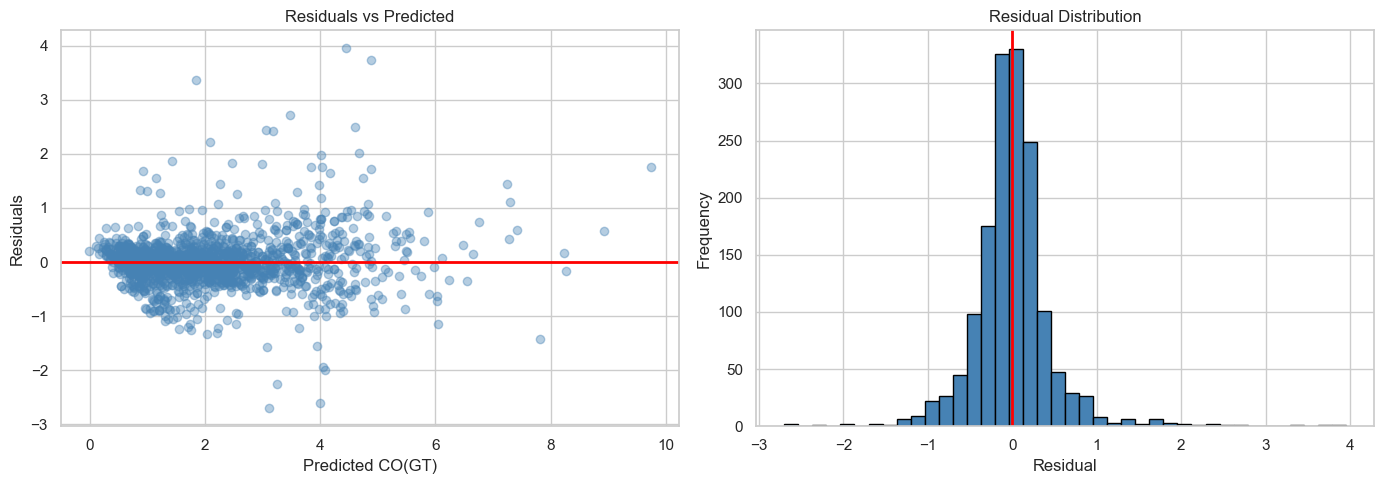

In [41]:
print("Name: prakhar tyagi")
print("URN: 2481010")

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, color="steelblue")
axes[0].axhline(0, color="red", linewidth=2)
axes[0].set_xlabel("Predicted CO(GT)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="black")
axes[1].axvline(0, color="red", linewidth=2)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

In [42]:
print("Name: prakhar tyagi")
print("URN: 2481010")

import numpy as np

# One new sample — fill in realistic values in this order:
# PT08.S1(CO), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx),
# NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH
new_sample = pd.DataFrame([[
    1200,   # PT08.S1(CO)
    8.5,    # C6H6(GT)
    950,    # PT08.S2(NMHC)
    120.0,  # NOx(GT)
    1100,   # PT08.S3(NOx)
    100.0,  # NO2(GT)
    1500,   # PT08.S4(NO2)
    1050,   # PT08.S5(O3)
    15.0,   # T
    55.0,   # RH
    0.75    # AH
]], columns=FEATURES)

predicted_co = model.predict(new_sample)
print(f"Predicted CO(GT) for new sample: {predicted_co[0]:.4f} mg/m³")

Name: prakhar tyagi
URN: 2481010
Predicted CO(GT) for new sample: 1.8925 mg/m³
